# Mobile Price Analysis

## Load Data

In [1]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("data/mobile_price.csv")

seed = 42
np.random.seed(seed)

# Show basic information
print(df.shape)
df.head()

(2000, 21)


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## SVM

In [2]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['price_range']).values
y = df['price_range'].values

# Split into train (60%) + temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=seed, shuffle=True
)

# Split temp into val (20%) + test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=seed, shuffle=True
)

In [3]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

# Train a SVM classifier
svm = SVC(C=1.0, random_state=seed)
svm.fit(X_train, y_train)

results = []

for name, X, y in [
    ("Training", X_train, y_train),
    ("Validation", X_val, y_val),
    ("Testing", X_test, y_test)
]:
    pred = svm.predict(X)
    acc = accuracy_score(y, pred)
    f1 = f1_score(y, pred, average='macro')

    results.append([name, acc, f1])

results = pd.DataFrame(results, columns=["Dataset", "Accuracy", "F1-score"])
results

,Dataset,Accuracy,F1-score
0,Training,0.9450,0.944600
1,Validation,0.9450,0.945318
2,Testing,0.9575,0.956887


In [4]:
import matplotlib.pyplot as plt

# Parameter C
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

train_acc, val_acc, test_acc = [], [], []
train_f1, val_f1, test_f1 = [], [], []

for C in C_values:
    model = SVC(C=C, random_state=seed)
    model.fit(X_train, y_train)
    
    # predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)
    
    # accuracy
    train_acc.append(accuracy_score(y_train, train_pred))
    val_acc.append(accuracy_score(y_val, val_pred))
    test_acc.append(accuracy_score(y_test, test_pred))
    
    # f1
    train_f1.append(f1_score(y_train, train_pred, average='macro'))
    val_f1.append(f1_score(y_val, val_pred, average='macro'))
    test_f1.append(f1_score(y_test, test_pred, average='macro'))

results = pd.DataFrame({
    "train_acc": train_acc,
    "val_acc": val_acc,
    "test_acc": test_acc,
    "train_f1": train_f1,
    "val_f1": val_f1,
    "test_f1": test_f1
}, index=C_values)

results = results.round(4)
results

,train_acc,val_acc,test_acc,train_f1,val_f1,test_f1
0.001,0.2550,0.2450,0.2400,0.1016,0.0984,0.0968
0.010,0.4908,0.4875,0.4425,0.3673,0.3466,0.3399
0.100,0.9050,0.9025,0.9000,0.9049,0.9025,0.8988
1.000,0.9450,0.9450,0.9575,0.9446,0.9453,0.9569
10.000,0.9658,0.9575,0.9650,0.9658,0.9577,0.9646
100.000,0.9792,0.9725,0.9775,0.9792,0.9725,0.9774
1000.000,0.9900,0.9700,0.9775,0.9900,0.9700,0.9773
10000.000,0.9975,0.9700,0.9650,0.9975,0.9700,0.9646


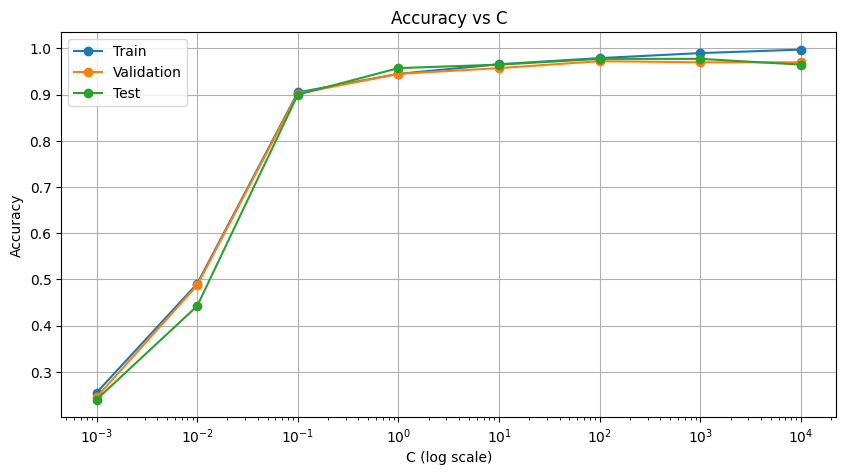

In [5]:
# Accuracy line plot
plt.figure(figsize=(10, 5))

plt.plot(C_values, train_acc, marker='o', label='Train')
plt.plot(C_values, val_acc, marker='o', label='Validation')
plt.plot(C_values, test_acc, marker='o', label='Test')

plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs C")
plt.legend()
plt.grid()
plt.show()

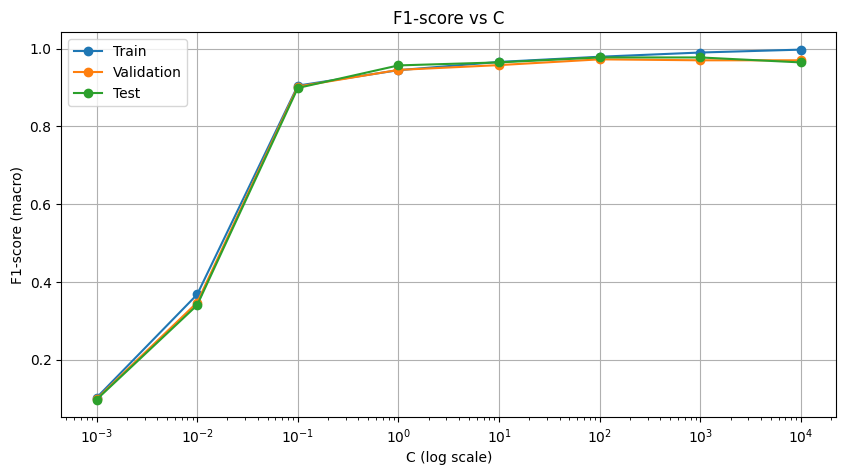

In [6]:
# F1-score line plot
plt.figure(figsize=(10, 5))

plt.plot(C_values, train_f1, marker='o', label='Train')
plt.plot(C_values, val_f1, marker='o', label='Validation')
plt.plot(C_values, test_f1, marker='o', label='Test')

plt.xscale('log')
plt.xlabel("C (log scale)")
plt.ylabel("F1-score (macro)")
plt.title("F1-score vs C")
plt.legend()
plt.grid()
plt.show()

## Association Rule Mining

In [7]:
# Filter the dataset
df_select = df[df['price_range'] == 1].copy()

# Focus on feature columns
cols = ["ram", "int_memory", "px_width", "battery_power"]
df_select = df_select[cols]

# Divide into categories
def discretize(series):
    min_val = series.min()
    max_val = series.max()
    range_val = max_val - min_val
    
    low_th = min_val + 0.3 * range_val
    high_th = min_val + 0.7 * range_val
    
    def categorize(x):
        if x <= low_th:
            return "low"
        elif x <= high_th:
            return "medium"
        else:
            return "high"
    
    return series.apply(categorize)

for col in cols:
    df_select[col] = discretize(df_select[col])

In [8]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth

# Transaction
transactions = []

for _, row in df_select.iterrows():
    transaction = [f"{col}_{row[col]}" for col in cols]
    transactions.append(transaction)
    
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

frequent_patterns = fpgrowth(
    df_trans,
    min_support=0.3,
    use_colnames=True
)

frequent_patterns = frequent_patterns.sort_values(by="support", ascending=False).reset_index(drop=True)

frequent_patterns_display = frequent_patterns.copy()
frequent_patterns_display["itemsets"] = frequent_patterns_display["itemsets"].apply(lambda x: ", ".join(sorted(list(x))))
frequent_patterns_display

,support,itemsets
0,0.682,ram_medium
1,0.416,px_width_medium
2,0.414,battery_power_medium
3,0.412,int_memory_medium
4,0.318,"battery_power_medium, ram_medium"
5,0.316,int_memory_low
6,0.308,battery_power_low
7,0.306,"px_width_medium, ram_medium"


In [9]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_patterns,
    metric="confidence",
    min_threshold=0.4
)

rules = rules[
    (rules['support'] >= 0.3) & 
    (rules['confidence'] >= 0.4) & 
    (rules['lift'] >= 0.8)
]

rules_display = rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
rules_display["antecedents"] = rules_display["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
rules_display["consequents"] = rules_display["consequents"].apply(lambda x: ", ".join(sorted(list(x))))
rules_display[["support", "confidence", "lift"]] = rules_display[["support", "confidence", "lift"]].round(4)
rules_display

,antecedents,consequents,support,confidence,lift
0,battery_power_medium,ram_medium,0.318,0.7681,1.1263
1,ram_medium,battery_power_medium,0.318,0.4663,1.1263
2,px_width_medium,ram_medium,0.306,0.7356,1.0786
3,ram_medium,px_width_medium,0.306,0.4487,1.0786


## PCA and K-Means

In [10]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['price_range']).values
y = df['price_range'].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

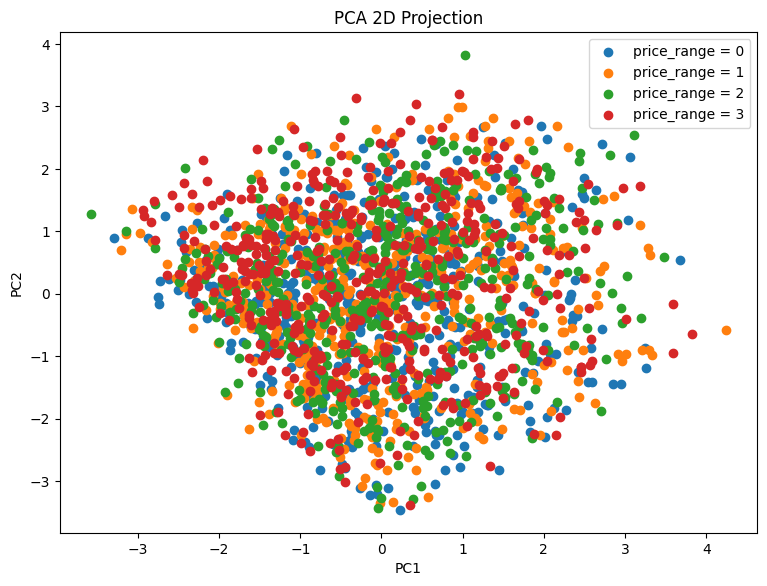

In [11]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 6.5))

for label in sorted(set(y)):
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=f"price_range = {label}"
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA 2D Projection")
plt.legend()
plt.show()

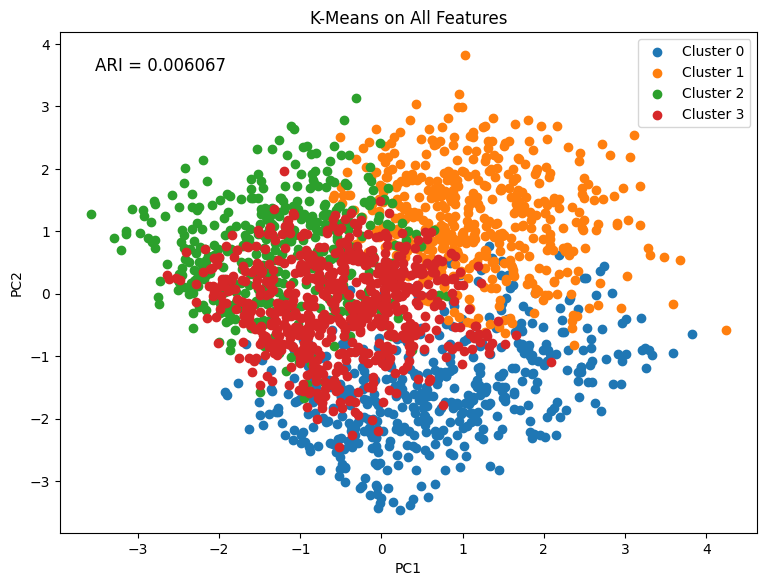

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

kmeans = KMeans(n_clusters=4, random_state=seed)
clusters = kmeans.fit_predict(X_scaled)
ari = adjusted_rand_score(y, clusters)

plt.figure(figsize=(9, 6.5))

for cluster in range(4):
    plt.scatter(
        X_pca[clusters == cluster, 0],
        X_pca[clusters == cluster, 1],
        label=f"Cluster {cluster}"
    )

plt.text(
    0.05, 0.95,
    f"ARI = {ari:.6f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means on All Features")
plt.legend()
plt.show()

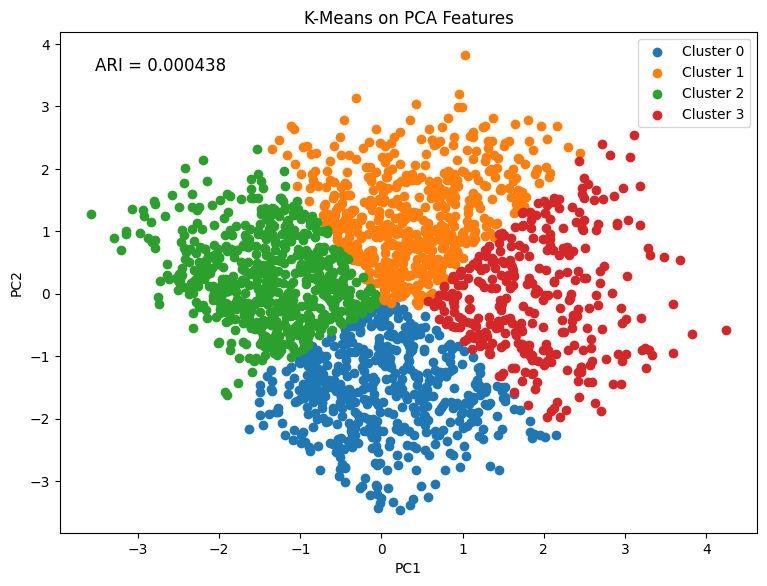

In [13]:
kmeans_pca = KMeans(n_clusters=4, random_state=seed)
clusters_pca = kmeans_pca.fit_predict(X_pca)
ari_pca = adjusted_rand_score(y, clusters_pca)

plt.figure(figsize=(9, 6.5))

for cluster in range(4):
    plt.scatter(
        X_pca[clusters_pca == cluster, 0],
        X_pca[clusters_pca == cluster, 1],
        label=f"Cluster {cluster}"
    )

plt.text(
    0.05, 0.95,
    f"ARI = {ari_pca:.6f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K-Means on PCA Features")
plt.legend()
plt.show()

## Enhancing K-means Clustering with ARM

In [14]:
df_select = df.copy()

cols = df.columns.drop("price_range")

for col in cols:
    df_select[col] = discretize(df_select[col])

transactions = []

for _, row in df_select.iterrows():
    transaction = [f"{col}_{row[col]}" for col in cols]
    transaction.append(f"price_range_{row['price_range']}")
    transactions.append(transaction)

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_array, columns=te.columns_)

In [15]:
frequent_patterns = fpgrowth(
    df_trans,
    min_support=0.2,
    use_colnames=True
)

rules = association_rules(
    frequent_patterns,
    metric="confidence",
    min_threshold=0.7
)

rules = rules[
    (rules['lift'] >= 3.0) &
    (rules['antecedents'].apply(lambda x: len(x) == 1 and not any('price_range' in item for item in x))) &
    (rules['consequents'].apply(lambda x: len(x) == 1 and any('price_range' in item for item in x)))
]

rules = rules.sort_values(
    by=["support", "confidence", "lift"],
    ascending=False
).reset_index(drop=True)

rules_display = rules[["antecedents", "consequents", "support", "confidence", "lift"]].copy()
rules_display["antecedents"] = rules_display["antecedents"].apply(lambda x: ", ".join(sorted(list(x))))
rules_display["consequents"] = rules_display["consequents"].apply(lambda x: ", ".join(sorted(list(x))))
rules_display[["support", "confidence", "lift"]] = rules_display[["support", "confidence", "lift"]].round(4)
rules_display

,antecedents,consequents,support,confidence,lift
0,ram_low,price_range_0,0.2305,0.7632,3.0530
1,ram_high,price_range_3,0.2250,0.7679,3.0717


In [16]:
important_features = list()

for _, row in rules.iterrows():
    for item in row['antecedents']:
        important_features.append(item.rsplit("_", 1)[0])

X_imp = df[important_features].copy()
X_all = df[cols].copy()

X_final = pd.concat([X_imp, X_all], axis=1)
X_final_scaled = scaler.fit_transform(X_final)

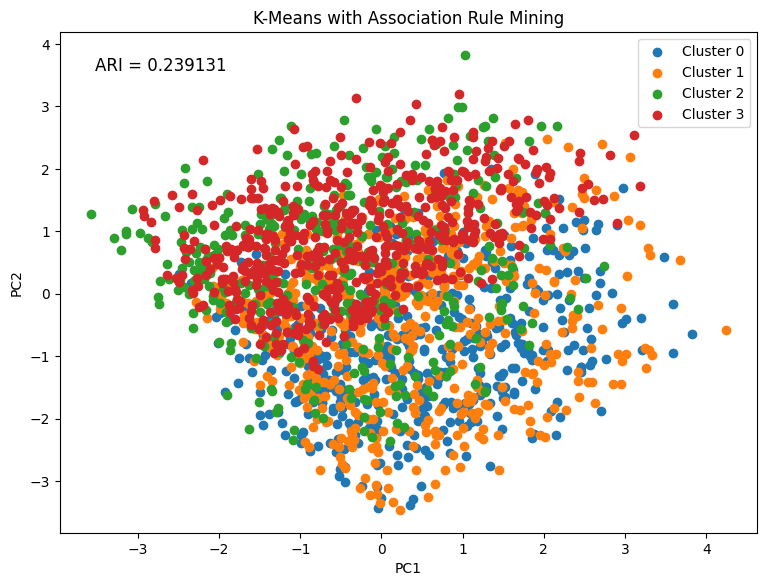

In [17]:
kmeans = KMeans(n_clusters=4, random_state=seed)
clusters = kmeans.fit_predict(X_final_scaled)
ari = adjusted_rand_score(y, clusters)

plt.figure(figsize=(9, 6.5))

for cluster in range(4):
    plt.scatter(
        X_pca[clusters == cluster, 0],
        X_pca[clusters == cluster, 1],
        label=f"Cluster {cluster}"
    )

plt.text(
    0.05, 0.95,
    f"ARI = {ari:.6f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment='top'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"K-Means with Association Rule Mining")
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import precision_score, recall_score

seeds = [0, 10, 42, 100, 999]

def evaluate_model(X, name):
    records = []
    
    for s in seeds:
        kmeans = KMeans(n_clusters=4, random_state=s)
        pred = kmeans.fit_predict(X)
        
        records.append({
            "seed": s,
            "ARI": adjusted_rand_score(y, pred),
            "Accuracy": accuracy_score(y, pred),
            "Precision": precision_score(y, pred, average="macro"),
            "Recall": recall_score(y, pred, average="macro"),
            "F1-Score": f1_score(y, pred, average="macro")
        })
    
    df_result = pd.DataFrame(records)

    mean_values = df_result.drop(columns=["seed"]).mean()
    mean_row = pd.DataFrame([["mean"] + list(mean_values)], columns=df_result.columns)

    df_result = pd.concat([df_result, mean_row], ignore_index=True)

    print(name)
    display(df_result)
    
    return df_result

orig_df = evaluate_model(X_scaled, "Original K-means")
improved_df = evaluate_model(X_final_scaled, "Improved K-means")

Original K-means


,seed,ARI,Accuracy,Precision,Recall,F1-Score
0,0,0.001595,0.2290,0.230251,0.2290,0.228744
1,10,0.001736,0.2415,0.239781,0.2415,0.239740
2,42,0.006067,0.2325,0.235068,0.2325,0.232261
3,100,0.003521,0.2655,0.264189,0.2655,0.263417
4,999,0.005832,0.2330,0.235622,0.2330,0.232700
5,mean,0.003750,0.2403,0.240982,0.2403,0.239372


Improved K-means


,seed,ARI,Accuracy,Precision,Recall,F1-Score
0,0,0.232123,0.3335,0.289763,0.3335,0.307587
1,10,0.230883,0.2180,0.229023,0.2180,0.221568
2,42,0.239131,0.2720,0.257485,0.2720,0.263249
3,100,0.248562,0.3865,0.331980,0.3865,0.348991
4,999,0.245293,0.3450,0.312097,0.3450,0.322690
5,mean,0.239199,0.3110,0.284070,0.3110,0.292817
